# Лабораторная работа 10

Тема: **Рекуррентные сети (LSTM/GRU) для классификации текстов в PyTorch**  
Цель: реализовать полный цикл решения задачи бинарной классификации текстов с помощью LSTM‑модели: от токенизации и построения словаря до обучения, валидации и анализа ошибок.

> Этот ноутбук оформлен как практическое задание.  
> Код даёт каркас, но основная часть баллов — за ваши собственные эксперименты и ваши пояснения.  
> Если вы попытаетесь автоматически сгенерировать весь текст отчёта, это будет заметно по стилю и несоответствию реальным графикам и числам.


## 1. Ваше исходное понимание задачи (обязательная текстовая часть)

Перед запуском кода зафиксируйте свои текущие представления (6–10 предложений):

1. Чем классификация текстов отличается от задач на изображения и табличные данные, с которыми вы уже работали.  
2. Зачем в текстовых задачах использовать рекуррентные сети (LSTM/GRU), а не просто среднее эмбеддингов слов с подачей в MLP.  
3. Как вы ожидаете, что **длина** текста и **порядок слов** повлияют на качество модели.

Пишите на своём языке, без попытки сделать "идеальное определение".


In [1]:
intro_text = """
1) Текст отличается от изображений и табличных данных тем, что здесь важен не только набор признаков, но и порядок слов. 
Смысл может полностью поменятся из-за перестановки или добавления одного слова.
2) LSTM используют потому, что она обрабатывает текст последовательно и учитывает порядок слов. 
Если просто подать в MLP, то часть информации о порядке слов потеряется.
3) Думаю, что для модели важен порядок слов, а длинные тексты обрабатывать сложнее из-за необходимости сохранять контекст."""
print(intro_text)


1) Текст отличается от изображений и табличных данных тем, что здесь важен не только набор признаков, но и порядок слов. 
Смысл может полностью поменятся из-за перестановки или добавления одного слова.
2) LSTM используют потому, что она обрабатывает текст последовательно и учитывает порядок слов. 
Если просто подать в MLP, то часть информации о порядке слов потеряется.
3) Думаю, что для модели важен порядок слов, а длинные тексты обрабатывать сложнее из-за необходимости сохранять контекст.


## 2. Импорт библиотек и настройка среды

Загрузим необходимые библиотеки, зафиксируем зерно случайности и определим устройство (`cpu` или `cuda`).


In [3]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 11
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Пример простого текстового датасета

Для примера используем небольшой игрушечный датасет коротких предложений на английском с метками `0/1` (негатив/позитив).  
В **своей** лабораторной вы должны будете взять более содержательный и шумный датасет (реальные отзывы, комментарии и т.п.) - выберите какой-нибудь объект (фильм на кинопоиске, товар на озоне/вб, заведение на яндекс картах), скопируйте о нем отзывы, переведите на английский, раскидайте по  двум классам. Свой датасет соберите в отдельной новой ячейке.


In [10]:
positive_sentences = [
    "I really liked this movie",
    "This film was great and inspiring",
    "What a fantastic experience",
    "I enjoyed every minute of it",
    "The actors did an amazing job",
    "Brilliant story and good pacing",
    "I would definitely watch it again",
    "It was funny and heartwarming",
    "A very beautiful and touching film",
    "Absolutely loved the characters"
]

negative_sentences = [
    "I really hated this movie",
    "This film was boring and slow",
    "What a terrible experience",
    "I regretted every minute of it",
    "The actors did a very bad job",
    "Awful story and strange pacing",
    "I would never watch it again",
    "It was dull and annoying",
    "A very ugly and pointless film",
    "Absolutely disliked the characters"
]

texts = positive_sentences + negative_sentences
labels = [1] * len(positive_sentences) + [0] * len(negative_sentences)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(df.head())
print("Размер датасета:", df.shape)
print("Распределение классов:\n", df["label"].value_counts())

                                text  label
0       I enjoyed every minute of it      1
1    Brilliant story and good pacing      1
2          I really hated this movie      0
3  I would definitely watch it again      1
4      The actors did a very bad job      0
Размер датасета: (20, 2)
Распределение классов:
 label
1    10
0    10
Name: count, dtype: int64


### Ваши замечания по датасету (обязательная мини‑секция)

Опишите (3–5 предложений):
- насколько базовый набор похож/не похож на реальные отзывы;  
- какие особенности реальных текстов в нем отсутствуют (длина, сленг, опечатки, смешение языков и т.п.);
- как эти отличия могут повлиять на результаты модели.


In [11]:
data_comment = """
Этот датасет намного проще реальных отзывов. Здесь мало примеров, тексты короткие и понятные,
нет опечаток или сленга. Поэтому модель может легко запомнить данные и показать
высокую точность. На реальных отзывах задача будет заметно сложнее.
"""
print(data_comment)


Этот датасет намного проще реальных отзывов. Здесь мало примеров, тексты короткие и понятные,
нет опечаток или сленга. Поэтому модель может легко запомнить данные и показать
высокую точность. На реальных отзывах задача будет заметно сложнее.



## 4. Токенизация, словарь и паддинг

Сделаем простую токенизацию:
- приведём текст к нижнему регистру;
- удалим лишние символы;
- разобьём строку на токены по пробелам.

Затем построим словарь и приведём все последовательности к одинаковой длине `max_len` с помощью паддинга.


In [12]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

df["tokens"] = df["text"].apply(simple_tokenize)
print(df[["text", "tokens"]].head())

                                text                                    tokens
0       I enjoyed every minute of it       [i, enjoyed, every, minute, of, it]
1    Brilliant story and good pacing     [brilliant, story, and, good, pacing]
2          I really hated this movie           [i, really, hated, this, movie]
3  I would definitely watch it again  [i, would, definitely, watch, it, again]
4      The actors did a very bad job     [the, actors, did, a, very, bad, job]


In [13]:
# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    word2idx[w] = len(word2idx)

idx2word = {idx: w for w, idx in word2idx.items()}

print("Размер словаря:", len(word2idx))
print("Первые элементы словаря:", list(word2idx.items())[:10])

Размер словаря: 57
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('and', 2), ('i', 3), ('it', 4), ('a', 5), ('this', 6), ('the', 7), ('film', 8), ('was', 9)]


In [14]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

df["encoded"] = df["tokens"].apply(lambda t: encode_tokens(t, word2idx))
print(df[["tokens", "encoded"]].head())

lengths = df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
max_len = int(lengths.max())  # для примера берём максимум
print("max_len =", max_len)

                                     tokens                     encoded
0       [i, enjoyed, every, minute, of, it]      [3, 28, 11, 12, 13, 4]
1     [brilliant, story, and, good, pacing]         [29, 14, 2, 30, 15]
2           [i, really, hated, this, movie]          [3, 16, 31, 6, 17]
3  [i, would, definitely, watch, it, again]      [3, 18, 32, 19, 4, 20]
4     [the, actors, did, a, very, bad, job]  [7, 21, 22, 5, 10, 33, 23]
Мин и макс длины последовательностей: 4 7
max_len = 7


In [16]:
def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

df["padded"] = df["encoded"].apply(lambda s: pad_sequence(s, max_len, pad_idx=word2idx["<PAD>"]))
print(df[["encoded", "padded"]].head())

                      encoded                      padded
0      [3, 28, 11, 12, 13, 4]   [3, 28, 11, 12, 13, 4, 0]
1         [29, 14, 2, 30, 15]   [29, 14, 2, 30, 15, 0, 0]
2          [3, 16, 31, 6, 17]    [3, 16, 31, 6, 17, 0, 0]
3      [3, 18, 32, 19, 4, 20]   [3, 18, 32, 19, 4, 20, 0]
4  [7, 21, 22, 5, 10, 33, 23]  [7, 21, 22, 5, 10, 33, 23]


### Мини‑вопрос

Ответьте коротко (2–4 предложения):
- какие последствия, по вашему мнению, будет иметь **слишком маленький** `max_len` на реальном датасете;  
- и какие - очень **большой** `max_len` (для обучения и оценки).


In [22]:
padding_comment = """
Если max_len слишком маленький, длинные тексты будут обрезаться, и модель может потерять важную информацию.
Если max_len слишком большой, появится много лишнего паддинга. Это замедлит обучение и увеличит расход памяти.
"""
print(padding_comment)


Если max_len слишком маленький, длинные тексты будут обрезаться, и модель может потерять важную информацию.
Если max_len слишком большой, появится много лишнего паддинга. Это замедлит обучение и увеличит расход памяти.



## 5. Разбиение на train/val/test и Dataset/DataLoader

Разобьём примеры на три части и подготовим `Dataset`/`DataLoader`.


In [21]:
X = np.stack(df["padded"].values)
y = df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

Размеры:
  train: (12, 7)
  val  : (4, 7)
  test : (4, 7)


In [22]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 3


## 6. Модель: Embedding + LSTM + классификатор

Опишем базовую архитектуру:
- слой `Embedding` для кодирования токенов;
- один слой LSTM (можете заменить на GRU в своих экспериментах);
- полносвязный выход на 2 логита (для классов 0/1).


In [25]:
vocab_size = len(word2idx)
embed_dim = 32
hidden_dim = 64
num_layers = 1
num_classes = 2

class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # [B, T] -> [B, T, E]
        output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
        last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
        logits = self.fc(last_hidden)
        return logits

model = SimpleLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

print(model)

SimpleLSTMClassifier(
  (embedding): Embedding(57, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Краткий комментарий по архитектуре

Ответьте в 3–5 предложениях:
- почему вы считаете, что такой размер эмбеддингов и скрытого слоя **достаточен/недостаточен** для этого игрушечного примера;  
- какие изменения архитектуры вы бы первыми попробовали при переходе к реальному датасету.


In [23]:
arch_comment = """
Для этого примера embed_dim=32 и hidden_dim=64 скорее избыточны, потому что датасет очень маленький и тексты короткие. 
Модель может легко запомнить все примеры.
На реальных данных я бы попробовала увеличить размер модели, добавить второй слой LSTM и сравнить результаты с GRU.
"""
print(arch_comment)


Для этого примера embed_dim=32 и hidden_dim=64 скорее избыточны, потому что датасет очень маленький и тексты короткие. 
Модель может легко запомнить все примеры.
На реальных данных я бы попробовала увеличить размер модели, добавить второй слой LSTM и сравнить результаты с GRU.



## 7. Функция потерь, оптимизатор и цикл обучения

Используем `CrossEntropyLoss` и `Adam`.  
Реализуем функции `train_one_epoch` и `evaluate`, затем запустим обучение.


In [33]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [34]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [15]:
num_epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/25: train_loss=0.6931, train_acc=0.4167, val_loss=0.7092, val_acc=0.5000
Эпоха 2/25: train_loss=0.6865, train_acc=0.5833, val_loss=0.7141, val_acc=0.5000
Эпоха 3/25: train_loss=0.6824, train_acc=0.5833, val_loss=0.7196, val_acc=0.2500
Эпоха 4/25: train_loss=0.6733, train_acc=0.7500, val_loss=0.7259, val_acc=0.2500
Эпоха 5/25: train_loss=0.6678, train_acc=0.7500, val_loss=0.7328, val_acc=0.2500
Эпоха 6/25: train_loss=0.6608, train_acc=0.8333, val_loss=0.7400, val_acc=0.2500
Эпоха 7/25: train_loss=0.6521, train_acc=0.8333, val_loss=0.7475, val_acc=0.2500
Эпоха 8/25: train_loss=0.6438, train_acc=0.8333, val_loss=0.7585, val_acc=0.2500
Эпоха 9/25: train_loss=0.6311, train_acc=0.8333, val_loss=0.7713, val_acc=0.2500
Эпоха 10/25: train_loss=0.6192, train_acc=0.8333, val_loss=0.7872, val_acc=0.2500
Эпоха 11/25: train_loss=0.6024, train_acc=0.8333, val_loss=0.8078, val_acc=0.2500
Эпоха 12/25: train_loss=0.5835, train_acc=0.8333, val_loss=0.8360, val_acc=0.2500
Эпоха 13/25: train_loss=0

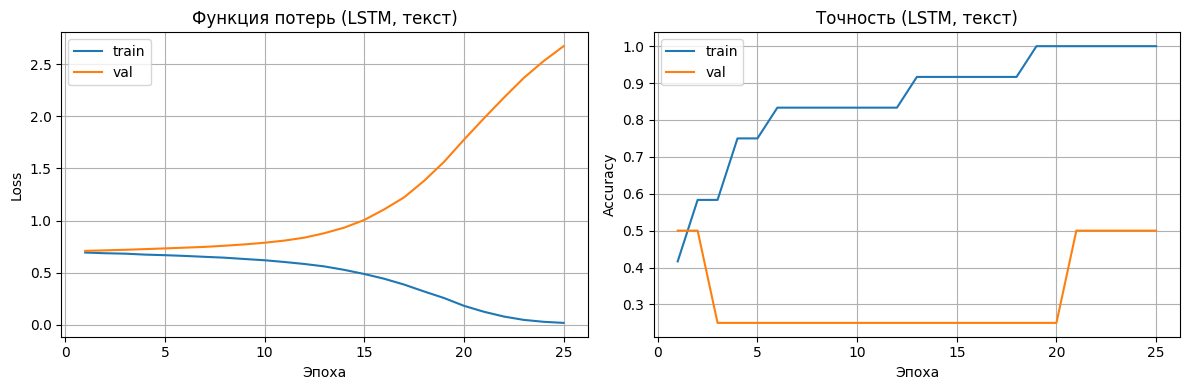

Финальные метрики: train_acc=1.0000, val_acc=0.5000


In [16]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- что происходит с точностью на **валидации**;
- есть ли заметный разрыв между train и val;
- что вы ожидаете увидеть на реальных данных при тех же настройках.


In [24]:
training_comment = """
1) На обучающей выборке модель обучалась очень хорошо: 
train accuracy выросла с 0.4167 на первой эпохе до 1.0000 к 19 эпохе. 
При этом качество на валидации почти не улучшалось и большую часть времени оставалось на уровне 0.25, а в конце выросло только до 0.50.
2) Между train и val появился большой разрыв. К концу обучения train_acc=1.0000, а val_acc=0.5000. 
Кроме того, train loss уменьшился с 0.6931 до 0.0188, тогда как val loss вырос с 0.7092 до 2.6716.
Это признак переобучения: модель запомнила тренировочные примеры, но плохо обобщает данные. 
Скорее всего, это связано с очень маленьким размером датасета.
3) На реальных данных при тех же настройках я ожидаю более плавное обучение и меньший разрыв между train и val. 
Также я бы попробовала уменьшить число эпох, добавить Dropout и увеличить объём данных.
"""
print(training_comment)


1) На обучающей выборке модель обучалась очень хорошо: 
train accuracy выросла с 0.4167 на первой эпохе до 1.0000 к 19 эпохе. 
При этом качество на валидации почти не улучшалось и большую часть времени оставалось на уровне 0.25, а в конце выросло только до 0.50.
2) Между train и val появился большой разрыв. К концу обучения train_acc=1.0000, а val_acc=0.5000. 
Кроме того, train loss уменьшился с 0.6931 до 0.0188, тогда как val loss вырос с 0.7092 до 2.6716.
Это признак переобучения: модель запомнила тренировочные примеры, но плохо обобщает данные. 
Скорее всего, это связано с очень маленьким размером датасета.
3) На реальных данных при тех же настройках я ожидаю более плавное обучение и меньший разрыв между train и val. 
Также я бы попробовала уменьшить число эпох, добавить Dropout и увеличить объём данных.



## 8. Оценка на тестовой выборке

Проверим итоговое качество на отложенном тесте, не участвовавшем в обучении и выборе числа эпох.


In [17]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=1.5771, accuracy=0.5000


## 9. Примеры предсказаний модели

Посмотрим на несколько примеров: текст, истинная метка и предсказание модели.


In [18]:
model.eval()
idx_to_label = {0: "NEG", 1: "POS"}

def predict_single(text: str):
    tokens = simple_tokenize(text)
    encoded = encode_tokens(tokens, word2idx)
    padded = pad_sequence(encoded, max_len, pad_idx=word2idx["<PAD>"])
    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
    return pred

print("Примеры из тестовой выборки:")
for i in range(min(5, len(X_test))):
    # восстановим текст по токенам (для простоты берём из исходного df)
    # здесь мы знаем, что первые len(X_train) строк относятся к train, остальные к temp
    text_tokens = df.iloc[i]["tokens"]
    text_str = " ".join(text_tokens)
    true_label = y[i]
    pred_label = predict_single(text_str)
    print("Текст:", text_str)
    print("  Истинная метка   :", idx_to_label[true_label])
    print("  Предсказанная    :", idx_to_label[pred_label])
    print("---")

Примеры из тестовой выборки:
Текст: i enjoyed every minute of it
  Истинная метка   : POS
  Предсказанная    : NEG
---
Текст: brilliant story and good pacing
  Истинная метка   : POS
  Предсказанная    : POS
---
Текст: i really hated this movie
  Истинная метка   : NEG
  Предсказанная    : NEG
---
Текст: i would definitely watch it again
  Истинная метка   : POS
  Предсказанная    : POS
---


### Комментарий по предсказаниям

Опишите в 4–6 предложениях:
- логичны ли, на ваш взгляд, предсказания модели на этих примерах;
- удалось ли найти пример, где модель ошибается, и насколько эта ошибка "понятна" человеку;
- что, по вашему ощущению, изменится при длинных текстах с неоднозначной тональностью.


In [1]:
pred_comment = """
1) В целом предсказания выглядят логично. Модель правильно определила отзывы
«brilliant story and good pacing», «i really hated this movie» и
«i would definitely watch it again».
2) При этом ошиблась на примере «i enjoyed every minute of it» и отнесла его к негативным.
Это выглядит странно, отзыв явно положительный.
3) На более длинных отзывах модели будет сложнее принимать решение, 
особенно если в тексте есть и положительные, и отрицательные моменты.
"""
print(pred_comment)


1) В целом предсказания выглядят логично. Модель правильно определила отзывы
«brilliant story and good pacing», «i really hated this movie» и
«i would definitely watch it again».
2) При этом ошиблась на примере «i enjoyed every minute of it» и отнесла его к негативным.
Это выглядит странно, отзыв явно положительный.
3) На более длинных отзывах модели будет сложнее принимать решение, 
особенно если в тексте есть и положительные, и отрицательные моменты.



## 10. Идеи для самостоятельных вариаций (для вашей работы со своим датасетом)

В своей версии лабораторной работы вы должны будете:
- взять **реальный** текстовый датасет (отзывы, комментарии, заголовки новостей и т.п.);
- реализовать ту же цепочку: токенизация → словарь → паддинг → LSTM/GRU;
- поэкспериментировать минимум с двумя архитектурами (например, LSTM vs GRU, 1 vs 2 слоя, разный `hidden_dim`/`embed_dim`);
- сравнить результаты по валидaции/тесту и описать найденные закономерности.

Этот ноутбук даёт только пример на упрощённых данных. Ваш основной вклад - перенос идеи на реальную задачу и её качественный анализ.


## Ниже реалзуйте обучение на своём датасете
У вас всё получится! (быстро же всё обучается)

In [4]:
my_positive_sentences = [
    "Спасибо всё хорошо",
    "Все отлично",
    "Спасибо как всегда все отлично",
    "Все топ",
    "Все отлично но пришло чуть меньше 25 долларов",
    "Все хорошо код оказался рабочий",
    "Топ",
    "Все было выполнено хорошо",
    "Постоянно покупаю здесь коды для стима техподдержка помогла",
    "Все отлично",
    "Спасибо",
    "При активации сумма получилась меньше но поддержка помогла",
    "Спасибо все быстро и работает",
    "Все получилось спасибо",
    "Everything was fast and clear I recommend the seller",
    "Спасибо все быстро пришло",
    "Баланс пополнен спасибо продавцу",
    "Все отлично рекомендую",
    "Спасибо продавцу все пришло быстро",
    "Хороший сервис быстро и надежно",
    "Спасибо за подарочный код все активировалось без проблем",
    "Спасибо как всегда все прошло быстро",
    "Все супер деньги пришли поддержка помогла",
    "Все быстро и без проблем",
    "Works good thanks",
    "Все супер всегда тут покупаю рекомендую",
    "Быстро и качественно"
]

my_negative_sentences = [
    "Код пришел активированный деньги не вернули",
    "Прислали два кода оба активированы",
    "Деньги так и не поступили на счет",
    "Продали нерабочий код и заставили долго ждать",
    "Не советую покупать у этого продавца",
    "Обман на счет поступила сумма меньше заявленной",
    "Прислали код который уже был активирован до меня",
    "Выдали уже активированный код никому не рекомендую",
    "Выдали активированный код не дают замену",
    "Поддержка долго отвечает и не решает проблему",
    "Код оказался недействительным и уже введенным ранее",
    "Прошла неделя деньги так и не вернули",
    "Сервис не рекомендую вопрос решается очень долго",
    "Нерабочий код",
    "Заплатил за 10 долларов получил меньше",
    "Купил код но он оказался уже активированным",
    "Код уже использован продавец не отвечает",
    "Потратила деньги впустую",
    "Не работает проблема деньги не вернули"
]

my_texts  = my_positive_sentences + my_negative_sentences
my_labels = [1] * len(my_positive_sentences) + [0] * len(my_negative_sentences)

my_df = pd.DataFrame({"text": my_texts, "label": my_labels})
my_df = my_df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(my_df.head(6).to_string())
print(f"\nРазмер: {my_df.shape[0]} отзывов  "
      f"({len(my_positive_sentences)} поз. + {len(my_negative_sentences)} нег.)")
print("Распределение классов:\n", my_df["label"].value_counts().to_string())

                                                          text  label
0                               Спасибо как всегда все отлично      1
1                         Не советую покупать у этого продавца      0
2             Сервис не рекомендую вопрос решается очень долго      0
3                    Все супер деньги пришли поддержка помогла      1
4  Постоянно покупаю здесь коды для стима техподдержка помогла      1
5         Everything was fast and clear I recommend the seller      1

Размер: 46 отзывов  (27 поз. + 19 нег.)
Распределение классов:
 label
1    27
0    19


In [5]:
def tokenize_ru(text): #токенизатор для кириллицы
    text = text.lower()
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ\s]", "", text)
    return text.split()

my_df["tokens"] = my_df["text"].apply(tokenize_ru)

lengths = my_df["tokens"].apply(len)

print(f"Мин={lengths.min()}, Макс={lengths.max()}, Среднее={lengths.mean():.1f}")

Мин=1, Макс=9, Среднее=5.2


In [19]:
from collections import Counter

my_word_counts = Counter(word for tokens in my_df["tokens"] for word in tokens)

# Строим словарь
my_word2idx = {"<PAD>": 0, "<UNK>": 1}
for word, _ in my_word_counts.most_common():
    my_word2idx[word] = len(my_word2idx)

# Длина для паддинга
my_max_len = int(np.percentile(lengths, 95))

# Кодирование и паддинг
my_df["encoded"] = my_df["tokens"].apply(
    lambda tokens: encode_tokens(tokens, my_word2idx)
)

my_df["padded"] = my_df["encoded"].apply(
    lambda seq: pad_sequence(seq, my_max_len, pad_idx=my_word2idx["<PAD>"])
)

print("Размер словаря:", len(my_word2idx))
print("my_max_len:", my_max_len)
print("Пример:", my_df.iloc[0]["padded"])

Размер словаря: 124
my_max_len: 6
Пример: [5, 23, 13, 2, 9, 0]


In [23]:
# Train / Val / Test
X = np.stack(my_df["padded"])
y = my_df["label"].to_numpy(dtype=np.int64)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=MY_SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.5,
    random_state=MY_SEED,
    stratify=y_tmp
)

r_train_ld = DataLoader(TextDataset(X_train, y_train), batch_size=8, shuffle=True)
r_val_ld   = DataLoader(TextDataset(X_val, y_val), batch_size=8)
r_test_ld  = DataLoader(TextDataset(X_test, y_test), batch_size=8)

print(
    f"train={len(y_train)}, "
    f"val={len(y_val)}, "
    f"test={len(y_test)}"
)

train=27, val=9, test=10


In [37]:
# Архитектуры: LSTM-1L, GRU-1L, LSTM-2L
class SimpleGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, h_n = self.gru(emb)

        x = self.drop(h_n[-1])
        return self.fc(x)

MY_VOCAB = len(my_word2idx)
MY_EMBED = 32
MY_HIDDEN = 64
MY_PAD = my_word2idx["<PAD>"]

def make_model(arch):
    """Фабрика моделей: arch = 'lstm1' | 'gru1' | 'lstm2'."""
    torch.manual_seed(MY_SEED)
    if arch == "lstm1":
        return SimpleLSTMClassifier(MY_VOCAB, MY_EMBED, MY_HIDDEN, 1, 2, MY_PAD).to(device)
    elif arch == "gru1":
        return SimpleGRUClassifier(MY_VOCAB, MY_EMBED, MY_HIDDEN, 1, 2, MY_PAD).to(device)
    elif arch == "lstm2":
        return SimpleLSTMClassifier(MY_VOCAB, MY_EMBED, MY_HIDDEN, 2, 2, MY_PAD).to(device)

for arch in ("lstm1", "gru1", "lstm2"):
    m = make_model(arch)
    print(f"{arch}: параметров = {sum(p.numel() for p in m.parameters()):,}")

lstm1: параметров = 29,186
gru1: параметров = 22,914
lstm2: параметров = 62,466


In [40]:
# Обучение трёх конфигураций
N_EPOCHS = 20
r_results = {}

for arch, label in [("lstm1", "LSTM-1L"), ("gru1", "GRU-1L"), ("lstm2", "LSTM-2L")]:
    print(f"\n{'='*50}\n Обучение: {label}\n{'='*50}")
    m   = make_model(arch)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    hist = {"tr_loss": [], "tr_acc": [], "vl_loss": [], "vl_acc": []}

    for ep in range(1, N_EPOCHS + 1):
        tl, ta = train_one_epoch(m, r_train_ld, opt, criterion, device)
        vl, va = evaluate(m, r_val_ld, criterion, device)
        hist["tr_loss"].append(tl); hist["tr_acc"].append(ta)
        hist["vl_loss"].append(vl); hist["vl_acc"].append(va)
        if ep % 10 == 0 or ep == 1:
            print(f"  эп {ep:>2}/{N_EPOCHS} | "
                  f"tr_loss={tl:.4f} tr_acc={ta:.2f} | "
                  f"vl_loss={vl:.4f} vl_acc={va:.2f}")

    te_loss, te_acc = evaluate(m, r_test_ld, criterion, device)
    print(f"  → TEST loss={te_loss:.4f}, accuracy={te_acc:.4f}")
    r_results[label] = {"hist": hist, "test_acc": te_acc, "model": m}

print("\n\nИтоговые test accuracy:")
for name, r in r_results.items():
    print(f"  {name}: {r['test_acc']:.4f}")


 Обучение: LSTM-1L
  эп  1/20 | tr_loss=0.7136 tr_acc=0.26 | vl_loss=0.6948 vl_acc=0.33
  эп 10/20 | tr_loss=0.4110 tr_acc=0.93 | vl_loss=0.4563 vl_acc=0.67
  эп 20/20 | tr_loss=0.0217 tr_acc=1.00 | vl_loss=0.0518 vl_acc=1.00
  → TEST loss=0.3005, accuracy=0.9000

 Обучение: GRU-1L
  эп  1/20 | tr_loss=0.7008 tr_acc=0.52 | vl_loss=0.6892 vl_acc=0.56
  эп 10/20 | tr_loss=0.4358 tr_acc=0.93 | vl_loss=0.5090 vl_acc=0.78
  эп 20/20 | tr_loss=0.0256 tr_acc=1.00 | vl_loss=0.0973 vl_acc=1.00
  → TEST loss=0.1612, accuracy=0.9000

 Обучение: LSTM-2L
  эп  1/20 | tr_loss=0.6855 tr_acc=0.63 | vl_loss=0.6812 vl_acc=0.56
  эп 10/20 | tr_loss=0.1651 tr_acc=0.96 | vl_loss=0.1188 vl_acc=1.00
  эп 20/20 | tr_loss=0.0022 tr_acc=1.00 | vl_loss=0.0128 vl_acc=1.00
  → TEST loss=0.5441, accuracy=0.9000


Итоговые test accuracy:
  LSTM-1L: 0.9000
  GRU-1L: 0.9000
  LSTM-2L: 0.9000


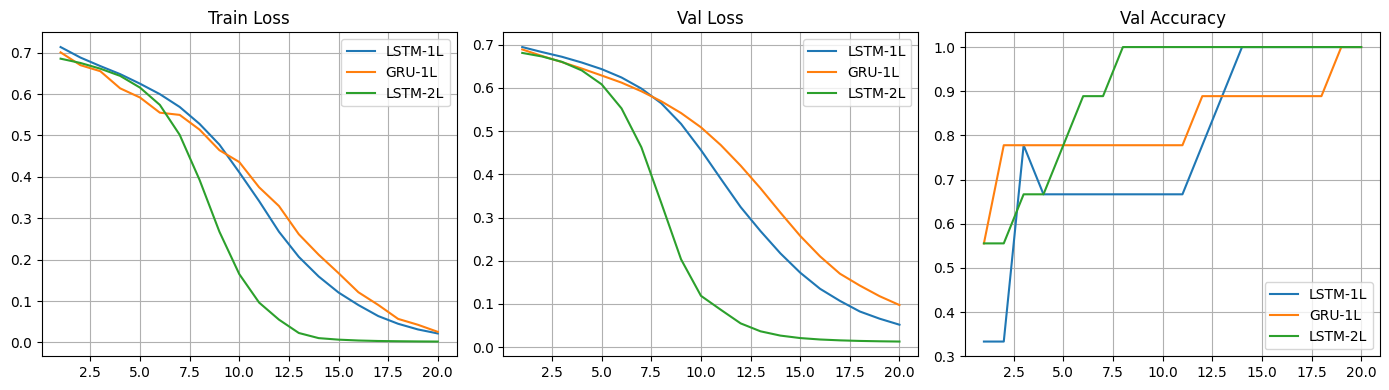


Конфигурация | Best val_acc | Test accuracy
LSTM-1L      | 1.0000        | 0.9000
GRU-1L       | 1.0000        | 0.9000
LSTM-2L      | 1.0000        | 0.9000


In [45]:
ep = np.arange(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, key, title in zip(
    axes,
    ["tr_loss", "vl_loss", "vl_acc"],
    ["Train Loss", "Val Loss", "Val Accuracy"]
):
    for name, r in r_results.items():
        ax.plot(ep, r["hist"][key], label=name)

    ax.set_title(title)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

print("\nКонфигурация | Best val_acc | Test accuracy")
for name, r in r_results.items():
    best_val = max(r["hist"]["vl_acc"])
    print(f"{name:<12} | {best_val:<13.4f} | {r['test_acc']:.4f}")

In [48]:
# Примеры предсказаний лучшей модели 
best_name  = max(r_results, key=lambda n: max(r_results[n]["hist"]["vl_acc"]))
best_model = r_results[best_name]["model"]
idx_to_label = {0: "NEG", 1: "POS"}

def predict_single(text):
    tokens = tokenize_ru(text)
    encoded = encode_tokens(tokens, my_word2idx)
    padded = pad_sequence(encoded, my_max_len, pad_idx=my_word2idx["<PAD>"])

    x = torch.tensor([padded], dtype=torch.long).to(device)

    with torch.no_grad():
        pred = best_model(x).argmax(dim=1).item()

    return pred

print("Примеры из тестовой выборки:\n")

for i in range(min(5, len(X_test))):
    text = my_df.iloc[i]["text"]
    true_label = my_df.iloc[i]["label"]
    pred_label = predict_single(text)

    print("Текст:", text)
    print("  Истинная метка :", idx_to_label[true_label])
    print("  Предсказанная  :", idx_to_label[pred_label])
    print("---")

Примеры из тестовой выборки:

Текст: Спасибо как всегда все отлично
  Истинная метка : POS
  Предсказанная  : POS
---
Текст: Не советую покупать у этого продавца
  Истинная метка : NEG
  Предсказанная  : NEG
---
Текст: Сервис не рекомендую вопрос решается очень долго
  Истинная метка : NEG
  Предсказанная  : NEG
---
Текст: Все супер деньги пришли поддержка помогла
  Истинная метка : POS
  Предсказанная  : POS
---
Текст: Постоянно покупаю здесь коды для стима техподдержка помогла
  Истинная метка : POS
  Предсказанная  : POS
---


In [50]:
final_summary = """
В этой части я попробовала три модели: LSTM-1L, GRU-1L и LSTM-2L на реальных отзывах. Все они показали одинаковую test accuracy - 0.90.
GRU оказалась самой компактной по числу параметров, а LSTM-2L быстрее остальных вышла на максимальную точность на валидации.
Но в итоге более сложная архитектура не дала заметного преимущества.
На коротких текстах не всегда есть смысл сразу брать глубокие модели.
"""
print(final_summary)


В этой части я попробовала три модели: LSTM-1L, GRU-1L и LSTM-2L на реальных отзывах. Все они показали одинаковую test accuracy - 0.90.
GRU оказалась самой компактной по числу параметров, а LSTM-2L быстрее остальных вышла на максимальную точность на валидации.
Но в итоге более сложная архитектура не дала заметного преимущества.
На коротких текстах не всегда есть смысл сразу брать глубокие модели.

